In [1]:
%load_ext autoreload
%autoreload 2

In [19]:
import jax
import jax.numpy as jnp
import jax.nn as nn
import jax.typing as jt
import matplotlib.pyplot as plt
import time

In [3]:
from datasets import load_dataset
from jax.typing import ArrayLike, DTypeLike
from typing import Dict

/Users/krishnan/Nexus/projects/NMT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
ds = load_dataset("mnist")
ds

Using the latest cached version of the dataset since mnist couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'mnist' at /Users/krishnan/.cache/huggingface/datasets/mnist/mnist/0.0.0/77f3279092a1c1579b2250db8eafed0ad422088c (last modified on Tue Dec  9 16:53:17 2025).


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [12]:
ds = ds.with_format("numpy")

x_train = jnp.asarray(ds["train"]["image"], dtype=jnp.float32) / 255.0
y_train = jnp.asarray(ds["train"]["label"], dtype=jnp.int32)
x_test = jnp.asarray(ds["test"]["image"], dtype=jnp.float32) / 255.0
y_test = jnp.asarray(ds["test"]["label"], dtype=jnp.int32)

# Add a channel dimension: (batch, height, width, channels)
x_train = x_train[..., None]
x_test = x_test[..., None]

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28, 1), (60000,), (10000, 28, 28, 1), (10000,))

In [13]:
def visualize_training_example(index=0):
    image = x_train[index].squeeze()
    label = int(y_train[index])

    plt.figure(figsize=(3, 3))
    plt.imshow(image, cmap="gray")
    plt.title(f"Training example {index}, y = {label}")
    plt.axis("off")
    plt.show()

#visualize_training_example(7)

In [14]:
x_train = x_train.reshape(x_train.shape[0], -1)
x_test = x_test.reshape(x_test.shape[0], -1)

x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [15]:
def fc(W: ArrayLike, b: ArrayLike, inp : ArrayLike):
    return inp @ W.T + b

def forward(params : Dict, x : ArrayLike):
    ## Layer 1
    x = fc(params["W1"], params["b1"], x)
    ## Layer 1 Activation
    x = nn.relu(x)

    ## Layer 2
    x = fc(params["W2"], params["b2"], x)
    ## Layer 2 Activation
    x = nn.relu(x)

    ## Layer 3
    x = fc(params["W3"], params["b3"], x)
    return x

def loss_fn(params : Dict, x : ArrayLike, y : ArrayLike):
    logits = forward(params, x) ## logits -> (batch_size, 10)
    log_probs = nn.log_softmax(logits, axis=1)
    indices = jnp.arange(y.shape[0])
    loss = -log_probs[indices, y]

    return jnp.mean(loss)

@jax.jit
def train_onestep(params : Dict, x : ArrayLike, y : ArrayLike, lr : float = 0.01):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
    params = jax.tree.map(lambda p, g: p - lr * g, params, grads)
    
    return loss, params 


key = jax.random.key(42)
k1, k2, k3 = jax.random.split(key, 3)

params = {
    "W1" : jax.random.normal(k1, (32, 784)) * 0.01,
    "b1" : jnp.zeros((1, 32)),
    "W2" : jax.random.normal(k2, (16, 32)) * 0.01,
    "b2" : jnp.zeros((1, 16)),
    "W3" : jax.random.normal(k3, (10, 16)) * 0.01,
    "b3" : jnp.zeros((1, 10)),
}

batch_size = 64
for epoch in range(101):
    loss = 0.0
    for start in range(0, len(x_train), batch_size):
        x = x_train[start : start + batch_size]
        y = y_train[start : start + batch_size]

        loss, params = train_onestep(params, x, y)
    
    if epoch % 10 == 0:
        print(f"Loss at epoch ({epoch} / 100) is {loss}")


Loss at epoch (0 / 100) is 2.303861618041992
Loss at epoch (10 / 100) is 0.4323161840438843
Loss at epoch (20 / 100) is 0.1870039999485016
Loss at epoch (30 / 100) is 0.10123860090970993
Loss at epoch (40 / 100) is 0.09802448749542236
Loss at epoch (50 / 100) is 0.07993899285793304
Loss at epoch (60 / 100) is 0.06525103747844696
Loss at epoch (70 / 100) is 0.05590202286839485
Loss at epoch (80 / 100) is 0.044942863285541534
Loss at epoch (90 / 100) is 0.03776067495346069
Loss at epoch (100 / 100) is 0.030880291014909744


In [16]:
def inference(params : Dict, x : ArrayLike, y : ArrayLike):
    logits = forward(params, x)
    outputs = jnp.argmax(logits, axis= 1)
    predicted_correct = int(jnp.sum(outputs == y))
    print(f"Accuracy = {(predicted_correct/len(y)) * 100}")

inference(params, x_test, y_test)


Accuracy = 96.48


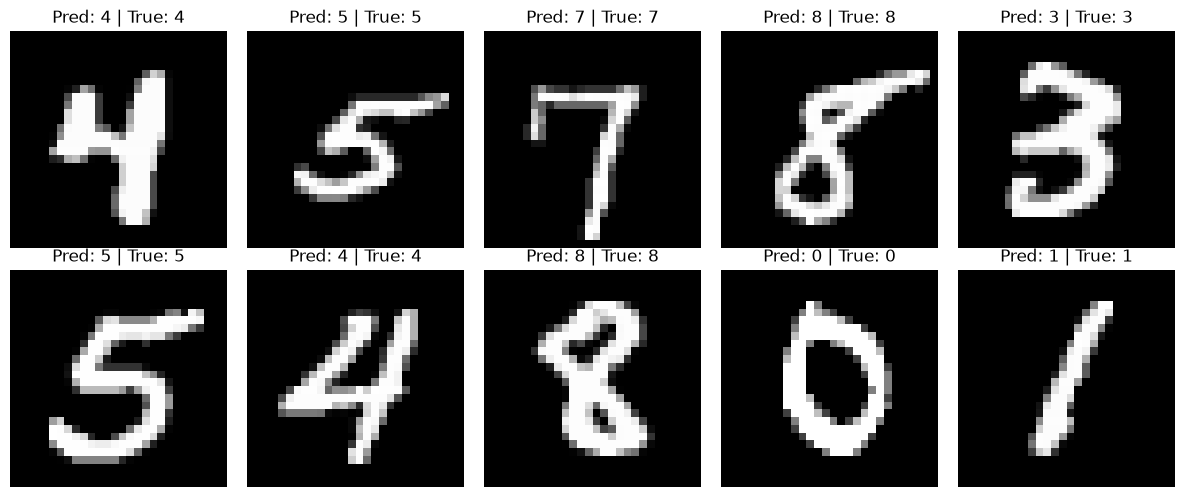

In [31]:
display_key = jax.random.key(int(time.time_ns()))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, ax in enumerate(axes):
    display_key, item_key = jax.random.split(display_key)
    index = int(jax.random.randint(item_key, shape=(), minval=0, maxval=len(x_test)))

    image = x_test[index].reshape(28, 28)
    true_label = int(y_test[index])
    logits = forward(params, x_test[index : index + 1])
    predicted_label = int(jnp.argmax(logits, axis=1)[0])

    ax.imshow(image, cmap="gray")
    ax.set_title(f"Pred: {predicted_label} | True: {true_label}")
    ax.axis("off")

plt.tight_layout()
plt.show()
